In [21]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from sklearn.datasets import make_blobs
from keras.models import Sequential
from keras.layers import Dense
from lab_utils_multiclass_TF import *
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)


In [22]:
# preparation of data
classes=4
m=100
centers=[[-5,2],[-2,-2],[1,2],[5,-2]]
std=1.0 # standard deviation
x_train,y_train=make_blobs(n_samples=m,centers=centers,cluster_std=std,random_state=30)


c:\Users\jyoti\OneDrive\Desktop\python\neural_networks\lab_utils_multiclass_TF.py:63: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(X[idx, 0], X[idx, 1],  marker=m,


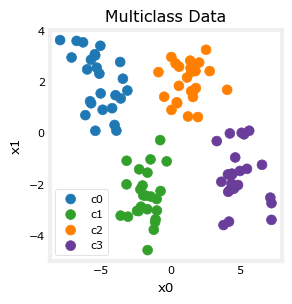

In [23]:
plt_mc(x_train,y_train,classes,centers,std=std)

In [24]:
# show classes in data set
print(f'unique classes {np.unique(y_train)}')
#show how classes are represented
print(f'class representation {y_train[:10]}')
# shapes of data set
print(f'shape of x_train: {x_train.shape}, shape of y_tarin: {y_train.shape}')

unique classes [0 1 2 3]
class representation [3 3 3 0 3 3 3 3 2 0]
shape of x_train: (100, 2), shape of y_tarin: (100,)


In [25]:
tf.random.set_seed(1234)
model=Sequential([
    Dense(units=2, activation='relu', name='l1'),
    Dense(units=4, activation='linear', name='l2')
]
)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.3184  
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1964 
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1022 
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0288 
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9701 
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9238 
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8871 
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8578 
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8332 
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8121 
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7939 
Epoch 12/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7776 
Epoch 13/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7625 
Epoch 14/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7486 
Epoch 15/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7358 
Epoch 16/200
4/4 ━

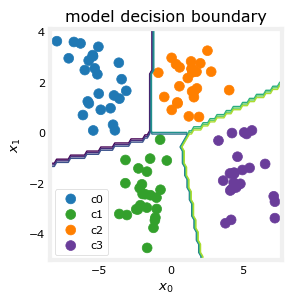

In [26]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.Adam(0.01)
)

model.fit(x_train,y_train,epochs=200)
plt_cat_mc(x_train,y_train,model,classes)

In [27]:
# gather trained parameters from first layer
l1=model.get_layer('l1')
w1,b1=l1.get_weights()

c:\Users\jyoti\OneDrive\Desktop\python\neural_networks\lab_utils_multiclass_TF.py:63: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(X[idx, 0], X[idx, 1],  marker=m,
c:\Users\jyoti\OneDrive\Desktop\python\neural_networks\lab_utils_multiclass_TF.py:63: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(X[idx, 0], X[idx, 1],  marker=m,


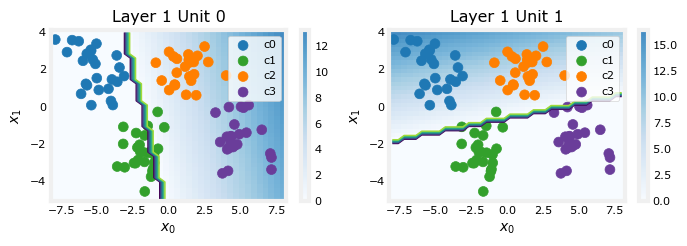

In [28]:
# plot the function of the first layer
plt_layer_relu(x_train, y_train.reshape(-1,), w1, b1, classes)

c:\Users\jyoti\OneDrive\Desktop\python\neural_networks\lab_utils_multiclass_TF.py:63: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(X[idx, 0], X[idx, 1],  marker=m,
c:\Users\jyoti\OneDrive\Desktop\python\neural_networks\lab_utils_multiclass_TF.py:63: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(X[idx, 0], X[idx, 1],  marker=m,
c:\Users\jyoti\OneDrive\Desktop\python\neural_networks\lab_utils_multiclass_TF.py:63: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(X[idx, 0], X[idx, 1],  marker=m,
c:\Users\jyoti\OneDrive\Desktop\python\neural_networks\lab_utils_multiclass_TF.py:63: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(X[idx, 0], X[idx, 1],  marker=m,


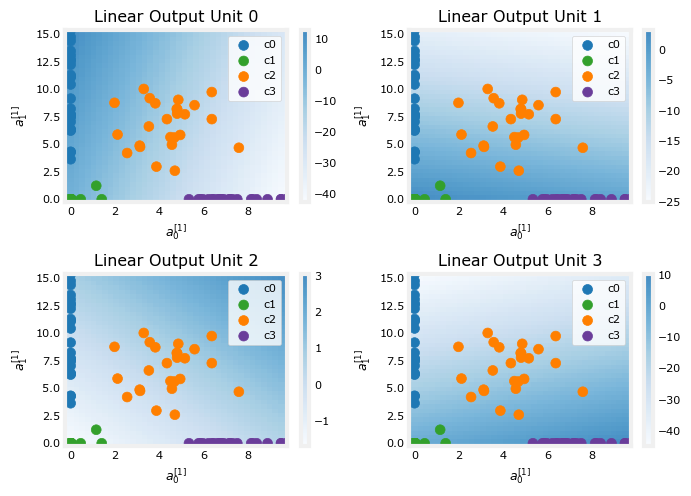

In [30]:
# gather trained parameters from output layer
l2=model.get_layer('l2')
w2,b2=l2.get_weights()

# create new features
xl2=np.maximum(0,np.dot(x_train,w1)+b1)
plt_output_layer_linear(xl2,y_train.reshape(-1,),w2,b2,classes,
                          x0_rng = (-0.25,np.amax(xl2[:,0])), x1_rng = (-0.25,np.amax(xl2[:,1])))